In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('Books_Data_Clean.csv')

In [4]:
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [8]:
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000
mean,535.926660,1994.730426,4.012230,94817.793855,1832.644985,841.360638,4.844311,613.314172,9744.482656
std,308.769358,23.204719,0.246492,31473.890412,3947.885096,2279.579848,3.561712,369.628663,15350.021050
min,0.000000,1901.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,271.000000,1989.000000,3.860000,70701.000000,366.300000,0.000000,1.990000,291.000000,570.000000
50%,535.000000,2003.000000,4.030000,89204.000000,792.000000,273.240000,3.990000,596.000000,3942.000000
75%,802.000000,2010.000000,4.180000,113400.000000,1470.260000,714.756000,6.990000,933.000000,5427.000000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


In [7]:
df = df[df['Publishing Year']>1900]

In [14]:
df.isna().sum()

index                   0
Publishing Year         0
Book Name               0
Author                  0
language_code          47
Author_Rating           0
Book_average_rating     0
Book_ratings_count      0
genre                   0
gross sales             0
publisher revenue       0
sale price              0
sales rank              0
Publisher               0
units sold              0
dtype: int64

In [13]:
df.dropna(subset = "Book Name",inplace=True)

In [15]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.nunique()

index                  988
Publishing Year        101
Book Name              987
Author                 669
language_code            8
Author_Rating            4
Book_average_rating    133
Book_ratings_count     983
genre                    4
gross sales            774
publisher revenue      570
sale price             143
sales rank             818
Publisher                9
units sold             470
dtype: int64

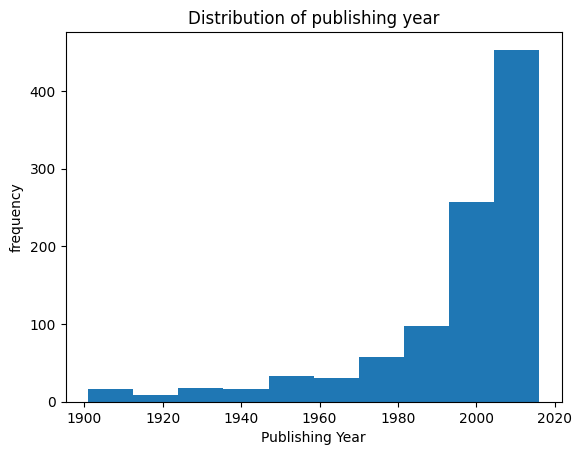

In [18]:
plt.hist(df['Publishing Year'])
plt.xlabel("Publishing Year")
plt.ylabel("frequency")
plt.title("Distribution of publishing year")
plt.show()

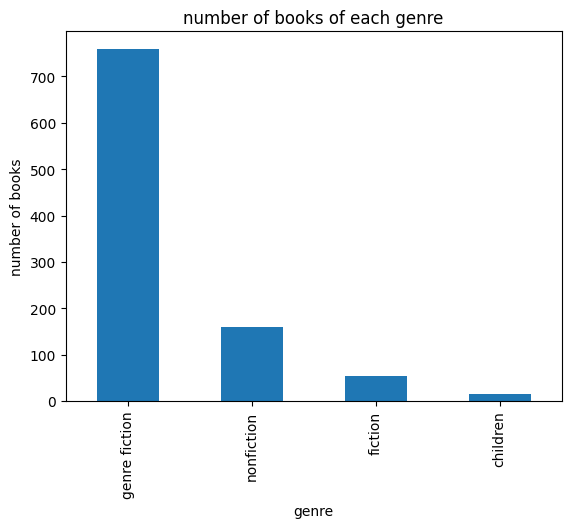

In [21]:
df['genre'].value_counts().plot(kind='bar')
plt.xlabel('genre')
plt.ylabel('number of books')
plt.title("number of books of each genre")
plt.show()

In [24]:
df.groupby('Author')['Book_average_rating'].mean().sort_values(ascending=False)

Author
Bill Watterson                  4.650000
Bill Watterson, G.B. Trudeau    4.610000
J.R.R. Tolkien                  4.590000
George R.R. Martin              4.560000
Sarah J. Maas                   4.526000
                                  ...   
Chetan Bhagat                   3.273333
Audrey Niffenegger              3.230000
Herman Koch, Sam Garrett        3.220000
P.D. James                      3.210000
Sue Monk Kidd                   3.100000
Name: Book_average_rating, Length: 669, dtype: float64

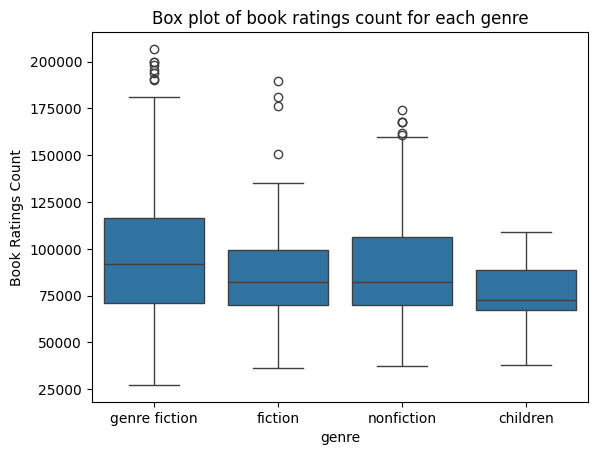

In [27]:
sns.boxplot(x='genre', y='Book_ratings_count', data = df)
plt.xlabel('genre')
plt.ylabel('Book Ratings Count')
plt.title('Box plot of book ratings count for each genre')
plt.show()

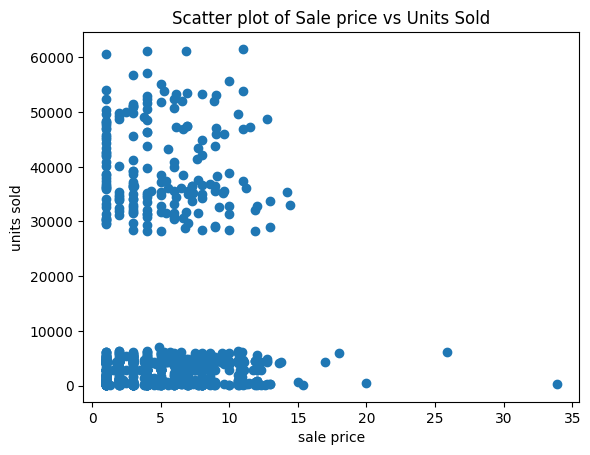

In [28]:
plt.scatter(df['sale price'], df['units sold'])
plt.xlabel("sale price")
plt.ylabel('units sold')
plt.title("Scatter plot of Sale price vs Units Sold")
plt.show()

In [30]:
language_counts = df['language_code'].value_counts()

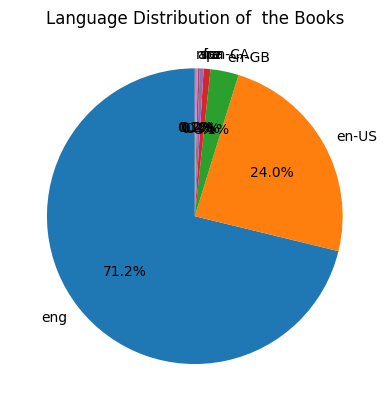

In [31]:
plt.pie(language_counts,labels=language_counts.index, startangle=90,autopct='%1.1f%%')
plt.title("Language Distribution of  the Books")
plt.show()

In [33]:
genre_type = df['genre'].value_counts()
genre_type

genre
genre fiction    759
nonfiction       160
fiction           54
children          15
Name: count, dtype: int64

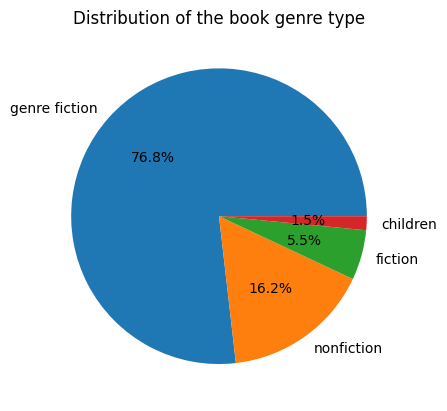

In [34]:
plt.pie(genre_type, labels=genre_type.index, autopct='%1.1f%%')
plt.title("Distribution of the book genre type")
plt.show()

In [39]:
num_of_pub = df['Publisher '].value_counts()
num_of_pub

Publisher 
Amazon Digital Services,  Inc.          561
Random House LLC                        113
Penguin Group (USA) LLC                  93
HarperCollins Publishers                 63
Hachette Book Group                      56
Simon and Schuster Digital Sales Inc     55
Macmillan                                39
HarperCollins Publishing                  4
HarperCollins Christian Publishing        4
Name: count, dtype: int64

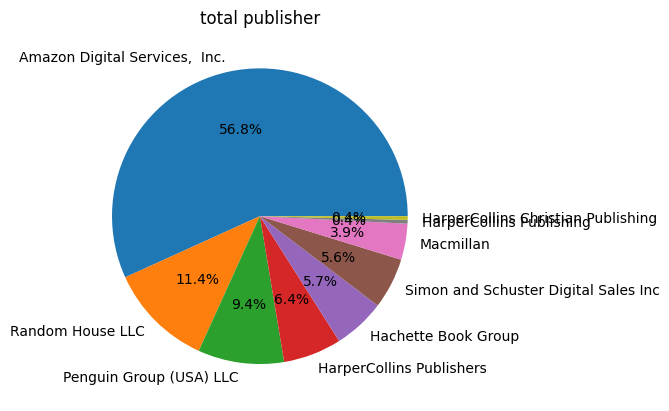

In [40]:
plt.pie(num_of_pub, labels=num_of_pub.index , autopct='%1.1f%%')
plt.title("total publisher")
plt.show()

<Axes: xlabel='Publisher '>

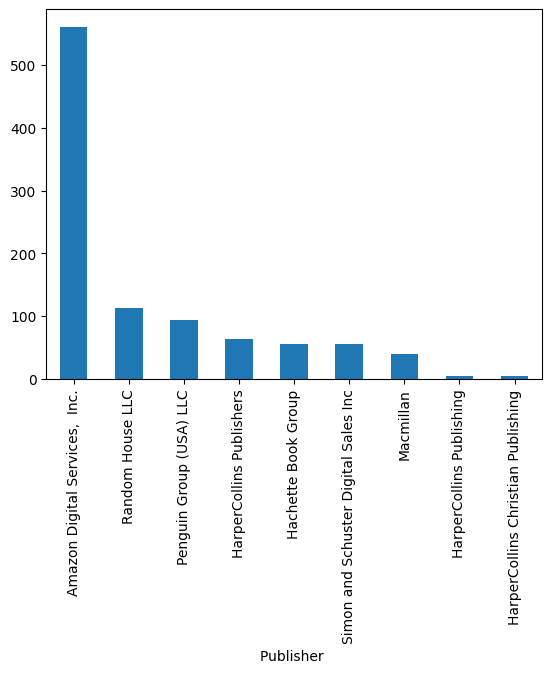

In [41]:
df['Publisher '].value_counts().plot(kind='bar')

In [43]:
df.groupby('Publisher ')['publisher revenue'].sum().sort_values(ascending=False)

Publisher 
Penguin Group (USA) LLC                 191581.104
Random House LLC                        174956.244
Amazon Digital Services,  Inc.          141767.772
HarperCollins Publishers                121769.814
Hachette Book Group                     107410.968
Simon and Schuster Digital Sales Inc     46858.206
Macmillan                                31249.830
HarperCollins Publishing                  2830.806
HarperCollins Christian Publishing        2135.670
Name: publisher revenue, dtype: float64

In [58]:
df.head(10)
# df.shape

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.00,20496.000,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.50,7462.500,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.00,28677.000,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.00,24750.000,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.50,22771.500,7.99,4,Penguin Group (USA) LLC,4750
5,5,2015.0,Red Queen,Victoria Aveyard,eng,Intermediate,4.08,83354,genre fiction,19960.00,0.000,4.99,5,"Amazon Digital Services, Inc.",4000
6,6,2011.0,The Power of Habit,Charles Duhigg,eng,Intermediate,4.03,155977,genre fiction,27491.67,16495.002,6.99,6,HarperCollins Publishers,3933
7,7,1994.0,Midnight in the Garden of Good and Evil,John Berendt,eng,Intermediate,3.90,167997,nonfiction,26182.00,15709.200,6.89,8,Hachette Book Group,3800
8,8,2012.0,Hopeless,Colleen Hoover,eng,Intermediate,4.34,189938,genre fiction,26093.67,15656.202,6.99,9,HarperCollins Publishers,3733
9,9,1905.0,A Little Princess,"Frances Hodgson Burnett, Nancy Bond",eng,Intermediate,4.20,199872,genre fiction,23792.34,14275.404,6.49,10,Random House LLC,3666


In [48]:
df.groupby("Author_Rating")['Book_ratings_count'].mean().sort_values(ascending=False)

Author_Rating
Intermediate    101400.272569
Famous           98295.250000
Novice           87318.464286
Excellent        83804.800595
Name: Book_ratings_count, dtype: float64

In [50]:
df.groupby('language_code').size().sort_values(ascending=False)

language_code
eng      670
en-US    226
en-GB     29
en-CA      7
fre        4
ara        2
spa        2
nl         1
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

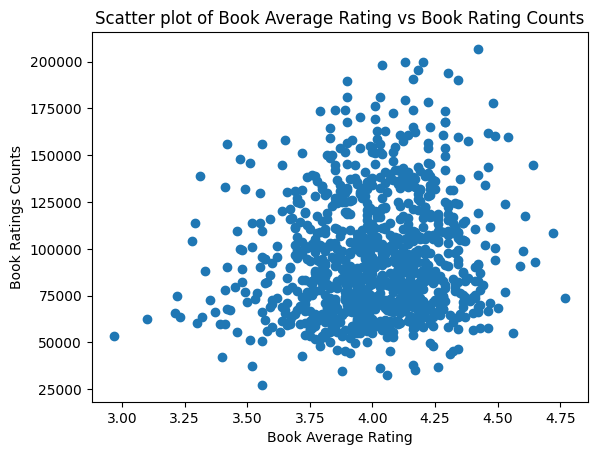

In [51]:
plt.scatter(df['Book_average_rating'],df['Book_ratings_count'])
plt.xlabel('Book Average Rating')
plt.ylabel('Book Ratings Counts')
plt.title("Scatter plot of Book Average Rating vs Book Rating Counts")
plt.show

In [53]:
total_gross_sale_by_author = df.groupby('Author')['gross sales'].sum()
total_gross_sale_by_author

Author
A.A. Milne, Ernest H. Shepard                       214.92
A.S.A. Harrison                                     784.16
Abbi Glines                                        2990.16
Adam Johnson                                        108.90
Adam Mansbach, Ricardo CortÃ©s                      113.85
                                                    ...   
William Styron                                      220.89
Yana Toboso, Tomo Kimura                           1366.86
Zadie Smith                                         167.31
Ø£Ø­Ù„Ø§Ù… Ù…Ø³ØªØºØ§Ù†Ù…ÙŠ, Ahlam Mosteghanemi    1200.10
Ø£Ø­Ù…Ø¯ Ù…Ø±Ø§Ø¯                                  1128.87
Name: gross sales, Length: 669, dtype: float64

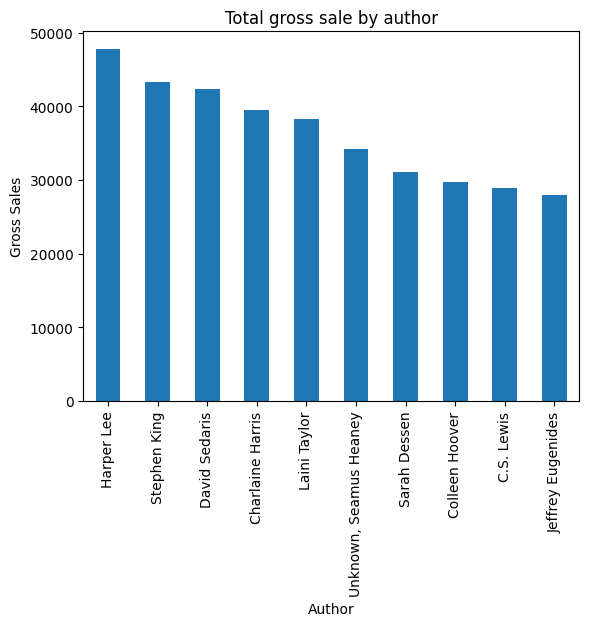

In [57]:
total_gross_sale_by_author.sort_values(ascending=False).head(10).plot(kind='bar')
plt.xlabel('Author')
plt.ylabel("Gross Sales")
plt.title("Total gross sale by author")
plt.show()

In [61]:
# df['Author'].value_counts()
df.groupby('Author')['Book Name'].value_counts()

Author                                           Book Name                   
A.A. Milne, Ernest H. Shepard                    The House at Pooh Corner        1
A.S.A. Harrison                                  The Silent Wife                 1
Abbi Glines                                      Fallen Too Far (Too Far, #1)    1
                                                 Never Too Far (Too Far, #2)     1
Adam Johnson                                     The Orphan Master's Son         1
                                                                                ..
William Styron                                   Sophie's Choice                 1
Yana Toboso, Tomo Kimura                         é»’åŸ·äº‹ I [Kuroshitsuji I]    1
Zadie Smith                                      White Teeth                     1
Ø£Ø­Ù„Ø§Ù… Ù…Ø³ØªØºØ§Ù†Ù…ÙŠ, Ahlam Mosteghanemi  Ø§Ù„Ø£Ø³ÙˆØ¯ ÙŠÙ„ÙŠÙ‚ Ø¨Ùƒ      1
Ø£Ø­Ù…Ø¯ Ù…Ø±Ø§Ø¯                                Ø§Ù„ÙÙŠÙ„ Ø§Ù„Ø£Ø²Ø±Ù‚         1
Name: cou

In [62]:
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [ ]:
df.groupby('Book Name')['units sold'].value_counts()


Book Name                                                                                                                     units sold
 A Monster Calls                                                                                                              4671          1
 Animal Farm & 1984                                                                                                           270           1
 The Tale of Despereaux                                                                                                       4455          1
'Salem's Lot The Illustrated Edition                                                                                          30672         1
1776                                                                                                                          660           1
                                                                                                                                           ..
ç¾Šã‚’ã‚ã

In [68]:
df.duplicated(subset=['Book Name', 'Author'])



0       False
1       False
2       False
3       False
4       False
        ...  
1065    False
1066    False
1067    False
1068    False
1069    False
Length: 988, dtype: bool

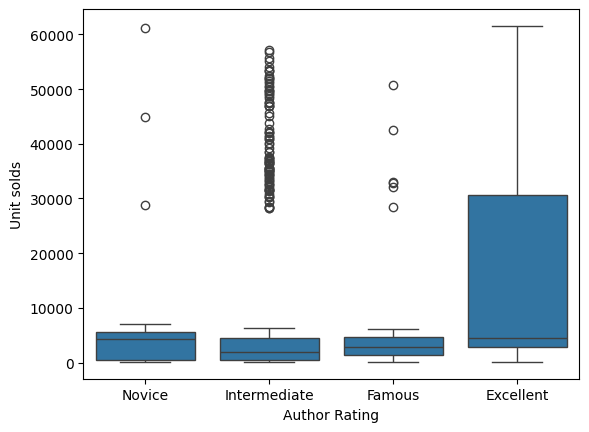

In [72]:
sns.boxplot(x=df['Author_Rating'],y=df['units sold'], data=df)
plt.xlabel("Author Rating")
plt.ylabel('Unit solds')
plt.show()

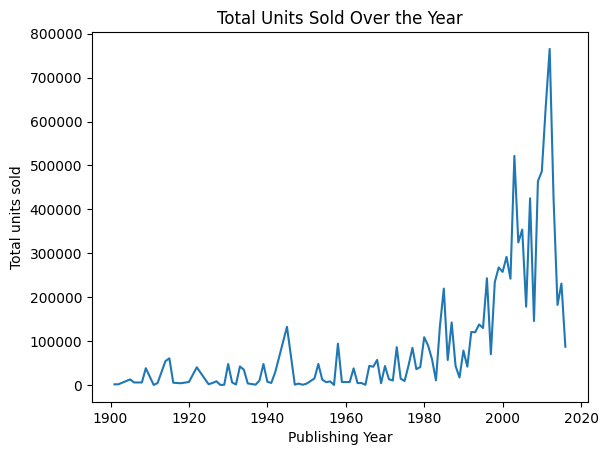

In [73]:
df.groupby('Publishing Year')['units sold'].sum().plot(kind='line')
plt.xlabel("Publishing Year")
plt.ylabel('Total units sold')
plt.title("Total Units Sold Over the Year")
plt.show()